In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

#rdkit warn off
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Eye Irritation\dataset\train_set_eye_irritation_features_rdkitcdk.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

# Modred handling calc
if 'Modred_Descriptor' in train_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    train_df['Modred_Descriptor'] = train_df['Modred_Descriptor'].apply(string_to_list_float)

print("Train DataFrame:")
print(train_df.head())
print(train_df.keys())


Train DataFrame:
  Outcome                                 Morgan_Descriptors  \
0       0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4       1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor    ID  \
0  [-1.0858958172735298, -1.372566035884163, -1.3...  1608   
1  [0.5078503976983185, 0.05839121285330338, 0.10...   617   
2  [-0.47515459257872156, 0.39000886268962404, 0....    13   
3  [-0.536425

In [3]:
train_df

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0858958172735298, -1.372566035884163, -1.3...",1608,CC(O)CO,76.052429496,-0.6405000000000001,31.057602761014792,40.46,...,2.0,3.0,4.0,0.3333333333333333,1.0,0.0,40.46,3.0,-0.748,1.0
1,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5078503976983185, 0.05839121285330338, 0.10...",617,CCCCCCCCCCCC[N+](C)(C)CCCS(=O)(=O)O,336.2566914960899,4.261600000000003,138.17676602501464,54.370000000000005,...,1.0,12.0,18.0,0.4705882352941176,15.0,2.0,62.75,5.392317422778761,5.019999999999998,1.0
2,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.47515459257872156, 0.39000886268962404, 0....",13,CCC1(CO)COCOC1,146.094294308,0.3794,60.94439677188973,38.69,...,1.0,2.0,2.0,0.4,2.0,0.0,38.69,4.321928094887363,0.2439999999999999,1.0
3,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5364250449069771, -1.0993449477973771, -1....",368,C=CCCCCCCCC,140.15650064,3.9230000000000027,65.33412702521478,0.0,...,0.0,10.0,10.0,0.4444444444444444,7.0,1.0,0.0,4.169925001442312,5.664,0.8
4,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0111170801950289, -1.1640682089309673, -1....",838,CC(O)CCO,90.06807956,-0.25039999999999996,37.4225448754114,40.46,...,2.0,4.0,5.0,0.5,2.0,0.0,40.46,3.321928094887362,-0.39,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1823,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9718916228574594, 0.39553883491703684, 0.45...",1645,OCCCOCC(COCCCO)(COCCCO)COCCCO,368.24101811199995,-0.4311999999999982,150.20944078498687,117.84000000000002,...,4.0,3.0,13.0,0.5,20.0,1.0,117.84000000000002,5.584962500721157,-1.75,1.0
1824,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4479577103546899, 0.3332568814599739, 0.39...",1102,O=C(O)c1ccc(O)c(O)c1,154.026608672,0.7959999999999998,62.34056859052537,77.76,...,3.0,0.0,3.0,0.5,1.0,0.0,77.76,4.459431618637298,0.986,0.0
1825,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0858958172735298, -1.372566035884162, -1.3...",1137,CCC(C)=O,72.057514876,0.9854,31.995599471063137,17.07,...,0.0,4.0,4.0,0.3333333333333333,1.0,0.0,17.07,3.0,0.438,0.75
1826,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.16152685598990882, -0.7174480082943241, -0....",1301,CCCCCCCCCCCCCC(=O)OC,242.2245802,4.8605000000000045,107.12350795893273,26.3,...,0.0,14.0,16.0,0.4666666666666667,13.0,2.0,26.3,5.0,6.752999999999998,0.9333333333333332


In [4]:
train_df= train_df.sort_values(['Outcome'], ascending=True)
train_df.head(100)

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0858958172735298, -1.372566035884163, -1.3...",1608,CC(O)CO,76.052429496,-0.6405000000000001,31.057602761014792,40.46,...,2.0,3.0,4.0,0.3333333333333333,1.0,0.0,40.46,3.0,-0.748,1.0
1459,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.030244522406833688, 0.6355786907582167, 0.7...",2134,COP(=S)(OC)Oc1cc(Cl)c(I)cc1Cl,411.835355106,4.494100000000002,122.75022171483076,27.69,...,0.0,0.0,5.0,0.5,4.0,1.0,69.59,5.0,5.489999999999999,0.25
1458,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.951268316448439, -1.0499930471440644, -1.0...",1602,CO[P+](=O)OC,109.00490710209,0.9365999999999999,37.20932893809189,35.53,...,0.0,0.0,5.0,0.5,2.0,0.0,35.53,3.321928094887362,-0.7420000000000001,1.0
1456,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2407228208736663, 0.9356286431485418, 1.01...",2173,C[Si]1(C)O[Si](C)(C)O[Si](C)(C)O[Si](C)(C)O1,296.07516536799994,2.8736000000000015,103.25277280587856,36.92,...,0.0,0.0,0.0,0.3333333333333333,0.0,0.0,36.92,5.0,4.5600000000000005,1.0
749,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5299624423347523, -0.6051841368109854, -0....",1513,CC(C)=CCCC(C)CCO,156.15141526,2.751300000000001,70.12836077741079,20.23,...,1.0,8.0,9.0,0.5,5.0,0.0,20.23,4.321928094887363,3.286,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4717216426613299, 0.03353380012611423, 0.0...",1219,CCC(C)c1ccccc1,134.109550448,3.2001000000000017,62.89117157708339,0.0,...,0.0,4.0,4.0,0.5,2.0,0.0,0.0,4.321928094887363,3.996000000000001,0.4
1406,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.609765268089576, -0.020928241732461463, 0....",1302,CCc1cccc(C)c1,120.093900384,2.5574200000000005,56.526229462686786,0.0,...,0.0,2.0,2.0,0.4,1.0,0.0,0.0,4.169925001442312,3.36,0.3333333333333333
794,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.07080547351670781, 0.37284411323478117, 0....",1684,C=CCOc1ccc(CC(=O)O)cc1Cl,226.039671892,2.5319000000000003,92.93907796792408,46.53,...,1.0,3.0,4.0,0.5,5.0,0.0,46.53,4.906890595608519,2.601,0.1818181818181818
795,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7089222229505214, 0.07259427279942421, -0....",1992,O=C1OCC(CO)O1,118.02660867200001,-0.48590000000000005,46.011092528743674,55.760000000000005,...,1.0,0.0,2.0,0.4,1.0,0.0,55.760000000000005,4.0,-0.47,0.75


In [5]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create the label encoder
le = LabelEncoder()

# Get unique outcomes
outcomes = np.unique(train_df['Outcome'])
le.fit(list(set(outcomes)))

# Transform the 'Outcome' column
y = le.transform(train_df['Outcome'])

# Print class information
print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", [len(y[y == smi]) for smi in np.unique(y)])
print("Total number of cpds             : ", len(y))

# Explicitly map the outcome classes
S = train_df['Outcome']

# Ensure the class mapping is applied explicitly and consistently
info = {0: 0, 1: 1}  # Ensure '0' is mapped to 0 and '1' is mapped to 1
S = S.replace(info)

# Print the class replacement info for reference
print("Class mapping: ", info)


Classes                          :  ['0' '1']
Number of cpds in each class     :  [923, 905]
Total number of cpds             :  1828
Class mapping:  {0: 0, 1: 1}


0    923
1    905
Name: Outcome, dtype: int64


{0: 0, 1: 1}

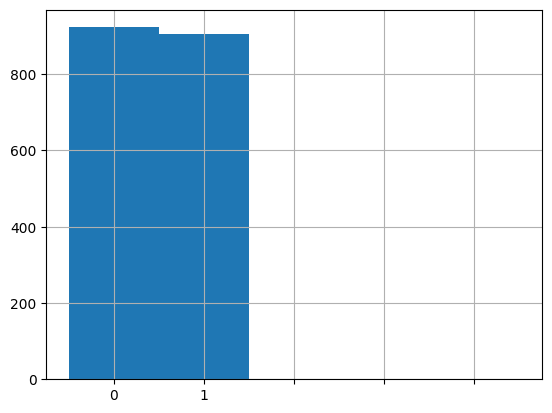

In [6]:
print(train_df['Outcome'].value_counts())

ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info


In [7]:
y= np.int32((S))
x = np.array(list(train_df['MACCS_Descriptors']))

In [8]:
print(x)

[[0 0 0 ... 1 0 0]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 1 0 0]
 ...
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 1 1 0]]


In [9]:
# Random Forest

from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# Parameter grid
paramgrid = {
    "max_features": [
        x.shape[1], x.shape[1] // 2, x.shape[1] // 4, x.shape[1] // 12,
        x.shape[1] // 10, x.shape[1] // 7, x.shape[1] // 5, x.shape[1] // 3
    ],
    "n_estimators": [10, 100, 300, 500],
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring function (Cohen's Kappa with quadratic weighting)
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV for Random Forest
model_rf_maccskey = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced"),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1  # Use all cores
)

# Fit the model
model_rf_maccskey.fit(x, y)

# Best model
best_model_rf_maccskey = model_rf_maccskey.best_estimator_

# Print best parameters and score
print("Best Params:", model_rf_maccskey.best_params_)
print("Best Score :", model_rf_maccskey.best_score_)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Params: {'max_features': 55, 'n_estimators': 100}
Best Score : 0.40534228813698914


In [10]:
#Random Forest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_rf_maccskey.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_maccskey.predict(X_test)
    y_proba = best_model_rf_maccskey.predict_proba(X_test)[:, 1]  
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[121  64]
 [ 56 125]]
Confusion Matrix for Fold 2:
[[137  48]
 [ 58 123]]
Confusion Matrix for Fold 3:
[[124  61]
 [ 56 125]]
Confusion Matrix for Fold 4:
[[129  55]
 [ 50 131]]
Confusion Matrix for Fold 5:
[[133  51]
 [ 57 124]]
Overall CV Accuracy: 0.6958559772438055
Overall CV AUC: 0.7552102823457616
Overall CV Precision: 0.693117884316526
Overall CV Recall (Sensitivity): 0.6939226519337016
Overall CV F1 Score: 0.693252778673974
Overall CV Specificity: 0.6977555816686252
Overall CV PPV (Positive Predictive Value): 0.693117884316526
Overall CV NPV (Negative Predictive Value): 0.6991478403446967
Overall CV CCR (Correct Classification Rate): 0.6958391168011635


In [11]:
# SVM

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid
paramgrid = {
    "C": [0.1, 1, 10, 50],       # Regularization parameter
    "kernel": ["rbf"],           # Type of kernel
    "gamma": ["scale", "auto"]   # Kernel coefficient
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring function (Cohen's Kappa with quadratic weighting)
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV for SVM
model_svm_maccskey = GridSearchCV(
    estimator=SVC(probability=True),  # probability=True if you need probability estimates
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1  # Use all cores
)

# Fit the model
model_svm_maccskey.fit(x, y)

# Best model
best_model_svm_maccskey = model_svm_maccskey.best_estimator_

# Print best parameters and score
print("Best Params:", model_svm_maccskey.best_params_)
print("Best Score :", model_svm_maccskey.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score : 0.4163098246593851


In [15]:
#SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_svm_maccskey.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_maccskey.predict(X_test)
    y_proba = best_model_svm_maccskey.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[129  56]
 [ 57 124]]
Confusion Matrix for Fold 2:
[[140  45]
 [ 46 135]]
Confusion Matrix for Fold 3:
[[132  53]
 [ 55 126]]
Confusion Matrix for Fold 4:
[[117  67]
 [ 55 126]]
Confusion Matrix for Fold 5:
[[137  47]
 [ 57 124]]
Overall CV Accuracy: 0.7056725802829553
Overall CV AUC: 0.7629462575715278
Overall CV Precision: 0.7041590886354161
Overall CV Recall (Sensitivity): 0.701657458563536
Overall CV F1 Score: 0.7026490586161436
Overall CV Specificity: 0.7096004700352526
Overall CV PPV (Positive Predictive Value): 0.7041590886354161
Overall CV NPV (Negative Predictive Value): 0.7077074074461611
Overall CV CCR (Correct Classification Rate): 0.7056289642993943


In [12]:
# XGB

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid
paramgrid = {
    "max_depth": [3, 5, 10],     # Common choices for tree depth
    "n_estimators": [100],       # Number of trees
    "learning_rate": [0.01, 0.1] # Step size shrinkage to prevent overfitting
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring function (Cohen's Kappa with quadratic weighting)
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV for XGB
model_xgb_maccskey = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric="mlogloss"),  # avoid warnings
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1  # Use all cores
)

# Fit the model
model_xgb_maccskey.fit(x, y)

# Best model
best_model_xgb_maccskey = model_xgb_maccskey.best_estimator_

# Print best parameters and score
print("Best Params:", model_xgb_maccskey.best_params_)
print("Best Score :", model_xgb_maccskey.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best Score : 0.4042062396839322


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [21:42:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [16]:
#XGB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_xgb_maccskey.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_maccskey.predict(X_test)
    y_proba = best_model_xgb_maccskey.predict_proba(X_test)[:, 1]  
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [21:49:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [21:49:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [21:49:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, Us

Confusion Matrix for Fold 1:
[[121  64]
 [ 55 126]]
Confusion Matrix for Fold 2:
[[139  46]
 [ 54 127]]
Confusion Matrix for Fold 3:
[[136  49]
 [ 61 120]]
Confusion Matrix for Fold 4:
[[114  70]
 [ 50 131]]
Confusion Matrix for Fold 5:
[[134  50]
 [ 52 129]]
Overall CV Accuracy: 0.6985747436185343
Overall CV AUC: 0.7635625620816588
Overall CV Precision: 0.6959465594342081
Overall CV Recall (Sensitivity): 0.6994475138121546
Overall CV F1 Score: 0.6970008468078311
Overall CV Specificity: 0.6976733254994124
Overall CV PPV (Positive Predictive Value): 0.6959465594342081
Overall CV NPV (Negative Predictive Value): 0.7027229285163286
Overall CV CCR (Correct Classification Rate): 0.6985604196557836


In [13]:
# NN

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Pipeline for preprocessing and NN
pipeline_nn = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # Handle NaN values
    ("scaler", StandardScaler()),                   # Scaling is essential for NN
    ("nn", MLPClassifier(
        max_iter=500,
        random_state=42,
        early_stopping=True
    ))
])

# Parameter grid (inspired by RF, SVM, XGB results)
paramgrid = {
    "nn__hidden_layer_sizes": [(256,), (256,128), (512,256,128)],  # moderate-to-deep capacity
    "nn__activation": ["relu"],                                    # nonlinear, consistent with SVM/XGB
    "nn__solver": ["adam"],                                        # adaptive optimizer
    "nn__alpha": [0.0001, 0.001],                                  # regularization strength
    "nn__learning_rate_init": [0.001]                              # stable learning rate
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring function (Cohen's Kappa with quadratic weighting)
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV for NN
model_nn_maccskey = GridSearchCV(
    estimator=pipeline_nn,
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# Fit the model
model_nn_maccskey.fit(x, y)

# Best model
best_model_nn_maccskey = model_nn_maccskey.best_estimator_

# Print best parameters and score
print("Best Params:", model_nn_maccskey.best_params_)
print("Best Score :", model_nn_maccskey.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'nn__activation': 'relu', 'nn__alpha': 0.001, 'nn__hidden_layer_sizes': (256, 128), 'nn__learning_rate_init': 0.001, 'nn__solver': 'adam'}
Best Score : 0.3748692882065819


In [17]:
#Neural Network NN
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model
    best_model_nn_maccskey.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_nn_maccskey.predict(X_test)
    y_proba = best_model_nn_maccskey.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[137  48]
 [ 67 114]]
Confusion Matrix for Fold 2:
[[142  43]
 [ 59 122]]
Confusion Matrix for Fold 3:
[[113  72]
 [ 58 123]]
Confusion Matrix for Fold 4:
[[116  68]
 [ 69 112]]
Confusion Matrix for Fold 5:
[[123  61]
 [ 55 126]]
Overall CV Accuracy: 0.6717523766749008
Overall CV AUC: 0.7323283787029883
Overall CV Precision: 0.6739771775065893
Overall CV Recall (Sensitivity): 0.6596685082872928
Overall CV F1 Score: 0.6658923774023473
Overall CV Specificity: 0.6835663924794361
Overall CV PPV (Positive Predictive Value): 0.6739771775065893
Overall CV NPV (Negative Predictive Value): 0.6713786531149797
Overall CV CCR (Correct Classification Rate): 0.6716174503833644


In [14]:
# LGBM

from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid inspired by RF, SVM, XGB results
paramgrid = {
    "max_depth": [7, 10],             # moderate to deep trees
    "n_estimators": [100, 300],       # number of boosting iterations
    "learning_rate": [0.05, 0.1],     # step size shrinkage
    "num_leaves": [31, 63],           # leaf complexity
    "min_child_samples": [20, 50]     # minimum data in leaf
}

# Cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring function (Cohen's Kappa with quadratic weighting)
kappa_scorer = make_scorer(cohen_kappa_score, weights="quadratic")

# GridSearchCV for LightGBM
model_lgbm_maccskey = GridSearchCV(
    estimator=LGBMClassifier(verbosity=-1, force_row_wise=True),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# Fit the model
model_lgbm_maccskey.fit(x, y)

# Best model
best_model_lgbm_maccskey = model_lgbm_maccskey.best_estimator_

# Print best parameters and score
print("Best Params:", model_lgbm_maccskey.best_params_)
print("Best Score :", model_lgbm_maccskey.best_score_)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63}
Best Score : 0.41958281182821333


In [18]:
# Evaluasi LGBM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

# Cross-validation setup
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Inisialisasi list metrik
accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model 
    best_model_lgbm_maccskey.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_lgbm_maccskey.predict(X_test)
    y_proba = best_model_lgbm_maccskey.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[126  59]
 [ 51 130]]
Confusion Matrix for Fold 2:
[[138  47]
 [ 57 124]]
Confusion Matrix for Fold 3:
[[126  59]
 [ 58 123]]
Confusion Matrix for Fold 4:
[[129  55]
 [ 53 128]]
Confusion Matrix for Fold 5:
[[141  43]
 [ 53 128]]
Overall CV Accuracy: 0.7073448611423011
Overall CV AUC: 0.7668142614149099
Overall CV Precision: 0.7073585252187495
Overall CV Recall (Sensitivity): 0.6994475138121548
Overall CV F1 Score: 0.7031007076461622
Overall CV Specificity: 0.7150998824911869
Overall CV PPV (Positive Predictive Value): 0.7073585252187495
Overall CV NPV (Negative Predictive Value): 0.7079869311340341
Overall CV CCR (Correct Classification Rate): 0.7072736981516707


In [19]:
# Save models 

import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Eye Irritation\model\fingerprint descriptor model"

joblib.dump(
    best_model_rf_maccskey,
    fr"{base_path}\Model_Eye_RF_maccskey.pkl",
    compress=9
)

joblib.dump(
    best_model_svm_maccskey,
    fr"{base_path}\Model_Eye_SVM_maccskey.pkl",
    compress=9
)

joblib.dump(
    best_model_xgb_maccskey,
    fr"{base_path}\Model_Eye_XGB_maccskey.pkl",
    compress=9
)

joblib.dump(
    best_model_nn_maccskey,
    fr"{base_path}\Model_Eye_NN_maccskey.pkl",
    compress=9
)

joblib.dump(
    best_model_lgbm_maccskey,
    fr"{base_path}\Model_Eye_LGBM_maccskey.pkl",
    compress=9
)


['C:\\Users\\User\\Documents\\KULIAH TELKOM S1\\SKRIPSI\\UJI COBA QSAR - PRIBADI\\Eye Irritation\\model\\fingerprint descriptor model\\Model_Eye_LGBM_maccskey.pkl']